## Numerical Root-finding

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la
import time


from scipy.linalg import eig
from scipy.optimize import newton
from scipy.interpolate import AAA
from g_nlevp import g_nlevp

## Task 1 - Contour-integration methods

In [2]:
# Define Function f(z)
def f(z):
    return np.exp(2*z) * np.cos(5*z) - 5*z**2



# Define Derivative f'(z)
def fp(z):
    return (
        np.exp(2*z)
        * (2*np.cos(5*z) - 5*np.sin(5*z))
        - 10*z
    )

## Task 1a

In [3]:
start_dlbh = time.perf_counter()

# Different numbers of quadrature points
M_values = [64, 128, 256, 512, 1024, 2048]

for M in M_values:

    # Equally spaced points on the unit circle
    j = np.arange(M)
    z = np.exp(2j * np.pi * j / M)

    # Periodic trapezoidal approximation
    values = z * fp(z) / f(z)

    # Cauchy argument principle + trapezoidal rule
    N = np.mean(values)

    print(f"M = {M:4d}, N = {N}")   




M =   64, N = (3.922939555211518-1.27675647831893e-15j)
M =  128, N = (4.001293611347297-4.718447854656915e-16j)
M =  256, N = (3.999992886316494+0j)
M =  512, N = (4.000000000011449+1.1102230246251565e-16j)
M = 1024, N = (4.000000000000001+0j)
M = 2048, N = (4.000000000000001-5.551115123125783e-17j)


In [4]:
N = np.mean(values)

print(f"M = {M:4d}, N = {N.real:.15f} + {N.imag:.2e}i")

M = 2048, N = 4.000000000000001 + -5.55e-17i


## Task 1b

In [5]:
# Number of roots from Task 1a is 4
N = 4

# Let M = 1024 be number of quadrature points
M = 1024

# Create quadrature points on the unit circle
j = np.arange(M)
zj = np.exp(2j * np.pi * j / M)

#f and f' at the quadrature points
f_values = f(zj)
fp_values = fp(zj)

#the moments
moments = np.zeros(2*N, dtype=complex)

for p in range(2*N):

    moments[p] = np.mean(
        zj**(p + 1)
        * fp_values
        / f_values
    )

print("Moments:")
print()

for p, Sp in enumerate(moments):

    print(
        f"S_{p} = "
        f"{Sp.real:.12e} "
        f"+ {Sp.imag:.12e}i"
    )




Moments:

S_0 = 4.000000000000e+00 + 0.000000000000e+00i
S_1 = -1.251466615937e+00 + 1.110223024625e-16i
S_2 = -1.677531893539e-02 + 0.000000000000e+00i
S_3 = 1.367399219818e+00 + 1.110223024625e-16i
S_4 = -1.621086132531e+00 + 5.551115123126e-17i
S_5 = 8.739795971416e-01 + -1.110223024625e-16i
S_6 = 3.505641453703e-01 + 2.220446049250e-16i
S_7 = -1.245728241316e+00 + 2.220446049250e-16i


In [6]:
#Construct H0 and H1
H0 = np.zeros((N, N), dtype=complex)
H1 = np.zeros((N, N), dtype=complex)
for i in range(N):

    for j in range(N):

        H0[i, j] = moments[i + j]

        H1[i, j] = moments[i + j + 1]
print("\nH0 =")
print(H0)
print("\nH1 =")
print(H1)



H0 =
[[ 4.        +0.00000000e+00j -1.25146662+1.11022302e-16j
  -0.01677532+0.00000000e+00j  1.36739922+1.11022302e-16j]
 [-1.25146662+1.11022302e-16j -0.01677532+0.00000000e+00j
   1.36739922+1.11022302e-16j -1.62108613+5.55111512e-17j]
 [-0.01677532+0.00000000e+00j  1.36739922+1.11022302e-16j
  -1.62108613+5.55111512e-17j  0.8739796 -1.11022302e-16j]
 [ 1.36739922+1.11022302e-16j -1.62108613+5.55111512e-17j
   0.8739796 -1.11022302e-16j  0.35056415+2.22044605e-16j]]

H1 =
[[-1.25146662+1.11022302e-16j -0.01677532+0.00000000e+00j
   1.36739922+1.11022302e-16j -1.62108613+5.55111512e-17j]
 [-0.01677532+0.00000000e+00j  1.36739922+1.11022302e-16j
  -1.62108613+5.55111512e-17j  0.8739796 -1.11022302e-16j]
 [ 1.36739922+1.11022302e-16j -1.62108613+5.55111512e-17j
   0.8739796 -1.11022302e-16j  0.35056415+2.22044605e-16j]
 [-1.62108613+5.55111512e-17j  0.8739796 -1.11022302e-16j
   0.35056415+2.22044605e-16j -1.24572824+2.22044605e-16j]]


In [7]:
#Solve the generalized eigenvalue problem
r = la.eigvals(H1, H0)
r = r[np.argsort(r.real)]

print("\nApproximate roots:")
print()

for k, root in enumerate(r, start=1):

    print(f"r_{k} = ", f"{root.real:.15f} ", f"+ {root.imag:.15f}i")




Approximate roots:

r_1 =  -0.646862129005919  + -0.699819334382368i
r_2 =  -0.646862129005919  + 0.699819334382368i
r_3 =  -0.228835977058323  + 0.000000000000005i
r_4 =  0.271093619133647  + 0.000000000000001i


In [8]:
dlbh_time = time.perf_counter() - start_dlbh
print(f"Total DL/BH time: {dlbh_time:.6f} s")

Total DL/BH time: 0.231914 s


In [9]:
#Calculate residual=|f(r_j)|
residuals = np.abs(f(r))

print("\nResiduals:")
print()

for k, (root, residual) in enumerate(
    zip(r, residuals),
    start=1
):

    print(
        f"|f(r_{k})| = "
        f"{residual:.6e}"
    )


Residuals:

|f(r_1)| = 2.801334e-14
|f(r_2)| = 3.351591e-14
|f(r_3)| = 1.695459e-13
|f(r_4)| = 1.300893e-13


In [10]:
#Check whether the roots are inside the unit disk
print("\nDistance from origin:")
print()

for k, root in enumerate(r, start=1):

    print(
        f"|r_{k}| = {abs(root):.12f}"
    )


Distance from origin:

|r_1| = 0.952983585754
|r_2| = 0.952983585754
|r_3| = 0.228835977058
|r_4| = 0.271093619134


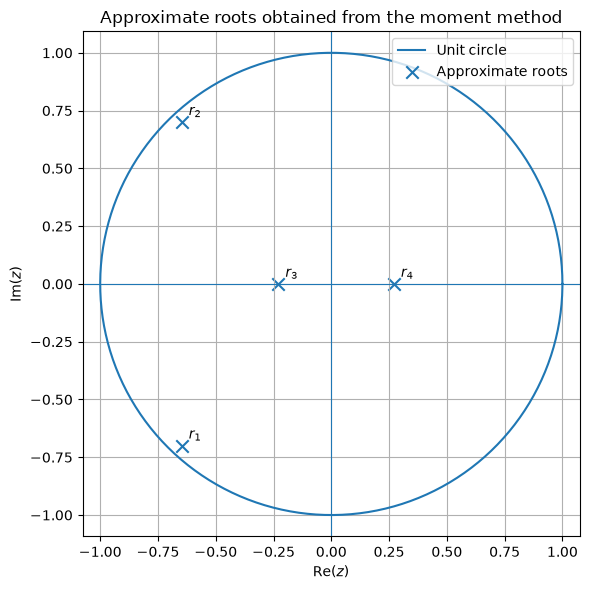

In [11]:
# Step 9: Plot the approximate roots
theta = np.linspace(0, 2*np.pi, 500)
unit_circle_x = np.cos(theta)
unit_circle_y = np.sin(theta)

plt.figure(figsize=(6, 6))
plt.plot(unit_circle_x, unit_circle_y, label="Unit circle")
plt.scatter(r.real, r.imag, marker="x", s=80, label="Approximate roots")

# Label each root
for k, root in enumerate(r, start=1):

    plt.annotate(f"$r_{k}$", (root.real, root.imag), xytext=(5, 5), textcoords="offset points")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel(r"$\operatorname{Re}(z)$")
plt.ylabel(r"$\operatorname{Im}(z)$")
plt.title("Approximate roots obtained from the moment method")
plt.axis("equal")
plt.grid(True)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Task 1c

In [12]:
# Approximate roots obtained from Task 1(b)
r = np.array([
    -0.6468621290059189 - 0.6998193343823675j,
    -0.6468621290059186 + 0.6998193343823683j,
    -0.2288359770583268 + 1.586454437091269e-15j,
     0.2710936191336444 - 5.579926200168003e-16j
])

refined_roots = []

for r0 in r:

    root = newton(
        f,
        r0,
        fprime=fp,
        tol=1e-14,
        maxiter=100
    )

    refined_roots.append(root)

refined_roots = np.array(refined_roots)

for k, (r0, root) in enumerate(
    zip(r, refined_roots),
    start=1
):

    print(f"\nRoot {k}")

    print("Initial approximation:")
    print(
        f"    {r0.real:.15f}"
        f" {r0.imag:+.15f}i"
    )

    print("Refined root:")
    print(
        f"    {root.real:.15f}"
        f" {root.imag:+.15f}i"
    )

    print("Residual:")
    print(
        f"    |f(r_{k})| = "
        f"{abs(f(root)):.6e}"
    )


Root 1
Initial approximation:
    -0.646862129005919 -0.699819334382368i
Refined root:
    -0.646862129005920 -0.699819334382367i
Residual:
    |f(r_1)| = 1.510067e-15

Root 2
Initial approximation:
    -0.646862129005919 +0.699819334382368i
Refined root:
    -0.646862129005920 +0.699819334382367i
Residual:
    |f(r_2)| = 1.510067e-15

Root 3
Initial approximation:
    -0.228835977058327 +0.000000000000002i
Refined root:
    -0.228835977058353 +0.000000000000000i
Residual:
    |f(r_3)| = 0.000000e+00

Root 4
Initial approximation:
    0.271093619133644 -0.000000000000001i
Refined root:
    0.271093619133635 -0.000000000000000i
Residual:
    |f(r_4)| = 5.551115e-17


## Task 1d


Ne = 1
cond(H0) = 1.0000e+00
Approximate roots:
  -0.312866653984 +0.000000000000i

Ne = 2
cond(H0) = 1.1628e+01
Approximate roots:
  -2.984939925156 -0.000000000000i
  -0.351068964531 +0.000000000000i

Ne = 3
cond(H0) = 9.9285e+00
Approximate roots:
  -0.617321391977 -0.670985015113i
  -0.617321391977 +0.670985015113i
  0.173724748978 +0.000000000000i

Ne = 4
cond(H0) = 1.6365e+02
Approximate roots:
  -0.646862129006 -0.699819334382i
  -0.646862129006 +0.699819334382i
  -0.228835977058 +0.000000000000i
  0.271093619134 +0.000000000000i

Ne = 5
cond(H0) = 4.6415e+15
Approximate roots:
  -0.646862129006 -0.699819334382i
  -0.646862129006 +0.699819334382i
  -0.228835977058 -0.000000000000i
  0.271093616159 +0.000000010081i
  0.271093621475 +0.000000085855i

Ne = 6
cond(H0) = 3.7744e+16
Approximate roots:
  -0.646862129006 -0.699819334382i
  -0.646862129006 +0.699819334382i
  -0.260880995912 -0.705106741819i
  -0.228835977058 -0.000000000000i
  0.271093619134 -0.000000000000i
  0.5400505

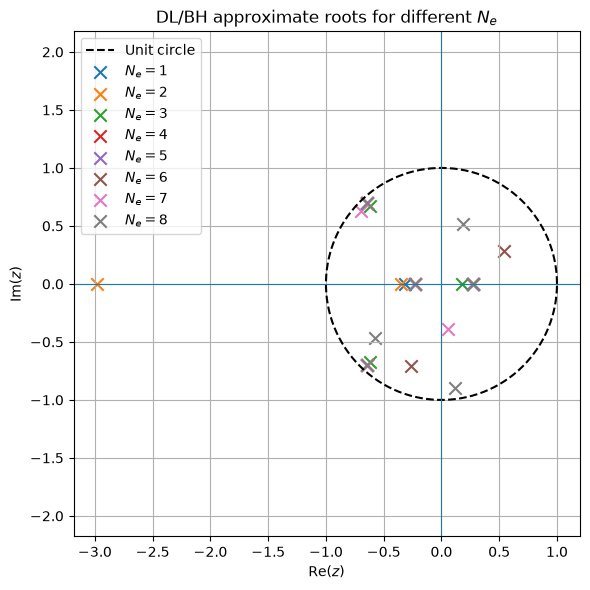

In [13]:
# Try different guesses for the number of roots

Ne_values = range(1, 9)

condition_numbers = []


plt.figure(figsize=(6, 6))
theta = np.linspace(0, 2*np.pi, 500)
plt.plot(np.cos(theta), np.sin(theta), 'k--', label="Unit circle")


for Ne in Ne_values:
    moments = np.zeros(2 * Ne, dtype=complex)
    for p in range(2 * Ne):
        moments[p] = np.mean(
            zj**(p + 1) * fp_values / f_values
        )

    H0 = np.zeros((Ne, Ne), dtype=complex)
    H1 = np.zeros((Ne, Ne), dtype=complex)

    for i in range(Ne):
        for k in range(Ne):
            H0[i, k] = moments[i + k]
            H1[i, k] = moments[i + k + 1]

    cond_H0 = np.linalg.cond(H0)
    condition_numbers.append(cond_H0)

    roots = la.eigvals(H1, H0)
    roots = roots[np.argsort(roots.real)]

    print(f"\nNe = {Ne}")
    print(f"cond(H0) = {cond_H0:.4e}")
    print("Approximate roots:")

    for root in roots:
        print(
            f"  {root.real:.12f} "
            f"{root.imag:+.12f}i"
        )

   

    plt.scatter(roots.real, roots.imag, marker="x", s=80, label=fr"$N_e={Ne}$")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel(r"$\operatorname{Re}(z)$")
plt.ylabel(r"$\operatorname{Im}(z)$")
plt.title("DL/BH approximate roots for different $N_e$")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

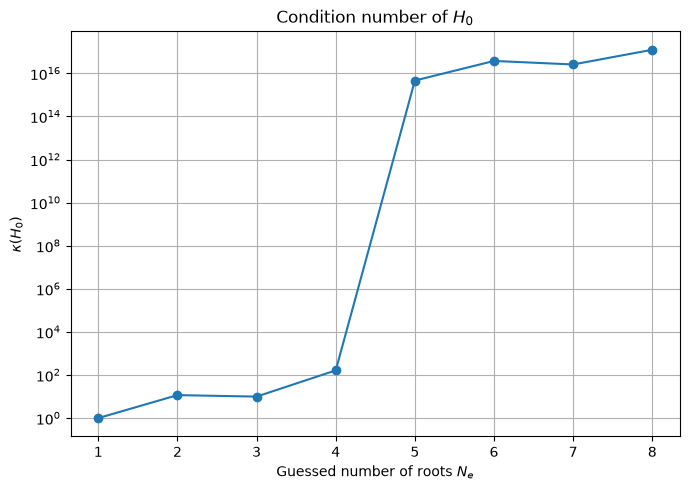

In [14]:
#Plot condition number vs Guessed number of roots

plt.figure(figsize=(7, 5))
plt.semilogy(
    list(Ne_values),
    condition_numbers,
    marker="o"
)
plt.xlabel(r"Guessed number of roots $N_e$")
plt.ylabel(r"$\kappa(H_0)$")
plt.title(r"Condition number of $H_0$")
plt.grid(True)
plt.tight_layout()
plt.show()

## Task 2 - Black-box solution of a nonlinear eigenvalue problem (NLEVP)

In [15]:
#Task 2b

In [16]:
# Load the data, skipping the header row
data = np.loadtxt("g_eval.csv", delimiter=",", skiprows=1)

# Construct the complex sampling points
z_eval = data[:, 0] + 1j * data[:, 1]

# Construct the complex values of g(z)
g_eval = data[:, 2] + 1j * data[:, 3]



In [17]:
start_aaa = time.perf_counter()

# Apply the AAA algorithm
r = AAA(z_eval, g_eval)

print(r)

In [18]:
poles = r.poles()

print("Number of poles:", len(poles))

for pole in poles:
    print(pole)

Number of poles: 40
(223248.74967695936-20207.2710535068j)
(-392.0161188877413+57081.69964689778j)
(88430.19721124989+78155.70749916004j)
(-2459.210303260777+40301.81163983986j)
(63439.24686426488+62809.47207290973j)
(-4824.304548905357+25412.720661087827j)
(-7426.082847205815+7010.951580581024j)
(141281.24428305103+2540.9963233986314j)
(154.13434741113142-69.20866272856198j)
(133202.9208137854+945.8398810195755j)
(7720.617615631688-1834.3641106665027j)
(9854.382704262196-1319.4138514855474j)
(10881.67865621597-717.4385062606877j)
(11459.473573237008-305.33778408869523j)
(11753.503186765447-66.25747328139715j)
(22345.11678376585+0.6449985985673576j)
(124224.78906844562+3037.155283814149j)
(106945.20763889537+25541.005215210113j)
(96977.57491949445+27540.988166775856j)
(87004.05164858964+28115.987015457507j)
(43857.60089797689+20.52553241344254j)
(44259.41857505891+3.5759869557585136j)
(54550.13915401828+459.51716102893255j)
(48142.06858696212+41.89161304786525j)
(48788.73198727385+6.32

In [19]:
aaa_time = time.perf_counter() - start_aaa
print(f"Total AAA time: {aaa_time:.6f} s")

Total AAA time: 1.838682 s


In [20]:
# Compute residuals
g = g_nlevp()

print("\nResiduals:")
for pole in poles:
    residual = 1 / abs(g(pole))
    print(pole, residual)


Residuals:
(223248.74967695936-20207.2710535068j) 3.59950313439615
(-392.0161188877413+57081.69964689778j) 0.9605066464654344
(88430.19721124989+78155.70749916004j) 1.6092678143145371
(-2459.210303260777+40301.81163983986j) 0.8321070574175067
(63439.24686426488+62809.47207290973j) 2.002430401827834
(-4824.304548905357+25412.720661087827j) 1.4850281352127022
(-7426.082847205815+7010.951580581024j) 2.937597346383588
(141281.24428305103+2540.9963233986314j) 1.7311070546083658
(154.13434741113142-69.20866272856198j) 0.024924037852406527
(133202.9208137854+945.8398810195755j) 0.8141796295165759
(7720.617615631688-1834.3641106665027j) 1.6978705202770428
(9854.382704262196-1319.4138514855474j) 2.167648933286101
(10881.67865621597-717.4385062606877j) 1.3713821030621642
(11459.473573237008-305.33778408869523j) 1.3213359493786725
(11753.503186765447-66.25747328139715j) 1.474781641561597
(22345.11678376585+0.6449985985673576j) 5.1397422390706146e-12
(124224.78906844562+3037.155283814149j) 4.1577

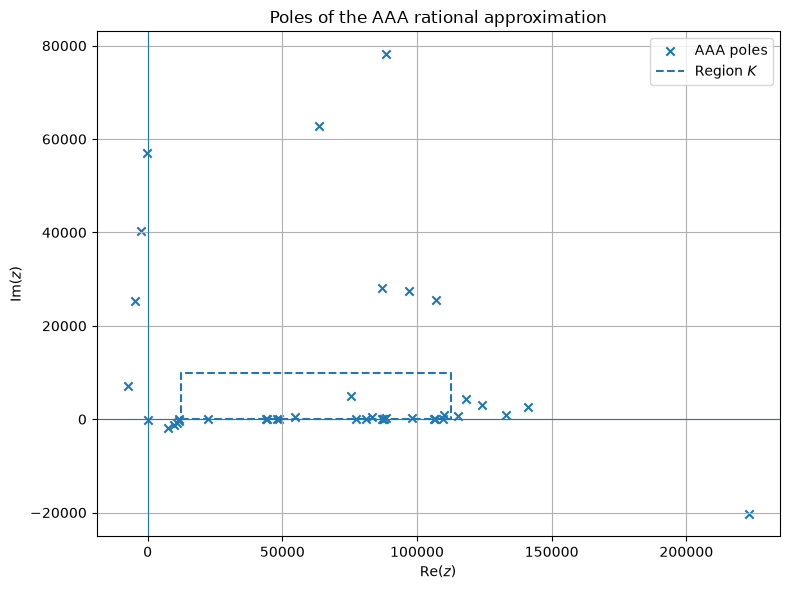

In [21]:
poles = r.poles()
plt.figure(figsize=(8, 6))
plt.scatter(poles.real, poles.imag, marker='x', label='AAA poles')
plt.plot(
    [12500, 112500, 112500, 12500, 12500],
    [0, 0, 10000, 10000, 0],
    linestyle='--',
    label=r'Region $K$'
)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel(r'$\operatorname{Re}(z)$')
plt.ylabel(r'$\operatorname{Im}(z)$')
plt.title('Poles of the AAA rational approximation')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

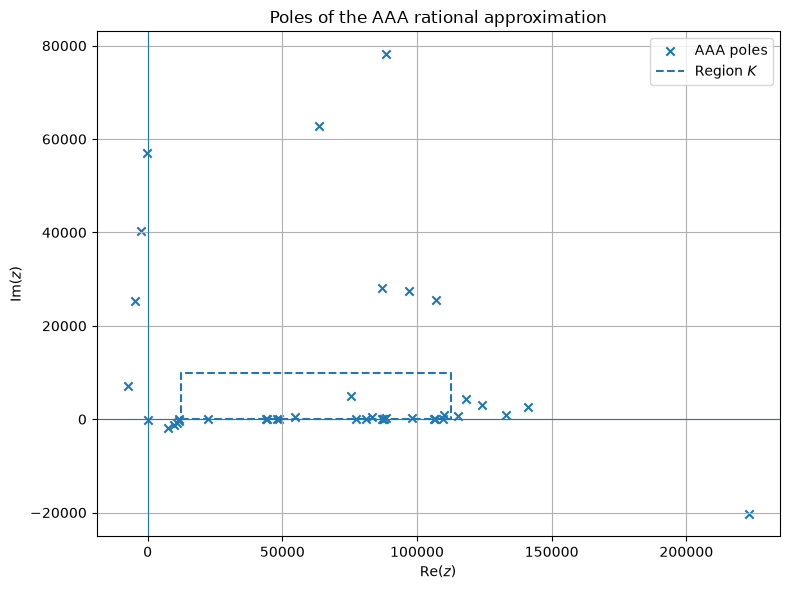

In [22]:
# Get the poles from the AAA approximation
poles = r.poles()

# Plot 1: All AAA poles
plt.figure(figsize=(8, 6))
plt.scatter(poles.real, poles.imag, marker='x', label='AAA poles')

# Plot the boundary of K
plt.plot(
    [12500, 112500, 112500, 12500, 12500],
    [0, 0, 10000, 10000, 0],
    '--',
    label=r'Region $K$'
)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel(r'$\operatorname{Re}(z)$')
plt.ylabel(r'$\operatorname{Im}(z)$')
plt.title('Poles of the AAA rational approximation')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




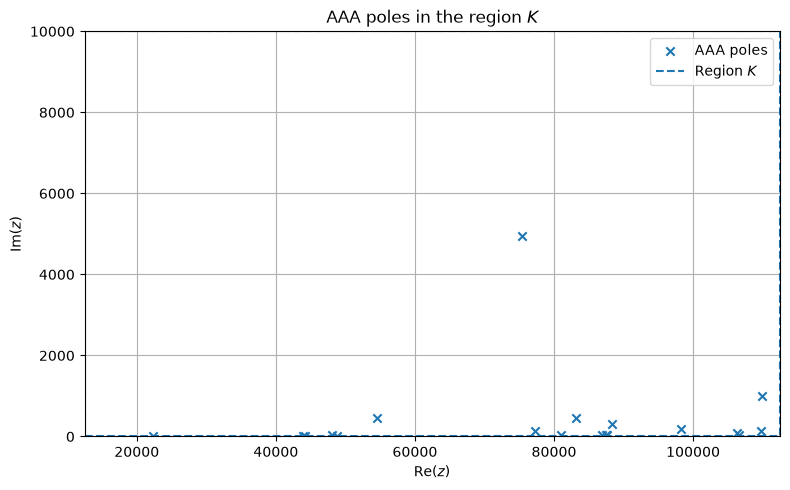

In [23]:
#Plot 2: Zoom into K
plt.figure(figsize=(8, 5))
plt.scatter(poles.real, poles.imag, marker='x', label='AAA poles')
plt.plot(
    [12500, 112500, 112500, 12500, 12500],
    [0, 0, 10000, 10000, 0],
    '--',
    label=r'Region $K$'
)
plt.xlim(12500, 112500)
plt.ylim(0, 10000)
plt.xlabel(r'$\operatorname{Re}(z)$')
plt.ylabel(r'$\operatorname{Im}(z)$')
plt.title('AAA poles in the region $K$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()